# **Modelling**
#### ***Loading Data***

In [6]:
import pandas as pd
df = pd.read_csv("/content/final_cleaned_dataset.csv")
print(df.columns.tolist())


['order_id', 'region_id_x', 'city_x', 'courier_id_x', 'accept_time_x', 'time_window_start', 'time_window_end', 'lng_x', 'lat_x', 'aoi_id_x', 'aoi_type_x', 'pickup_time', 'pickup_gps_time', 'pickup_gps_lng', 'pickup_gps_lat', 'accept_gps_time_x', 'accept_gps_lng_x', 'accept_gps_lat_x', 'ds_x', 'region_id_y', 'city_y', 'courier_id_y', 'lng_y', 'lat_y', 'aoi_id_y', 'aoi_type_y', 'accept_time_y', 'accept_gps_time_y', 'accept_gps_lng_y', 'accept_gps_lat_y', 'delivery_time', 'delivery_gps_time', 'delivery_gps_lng', 'delivery_gps_lat', 'ds_y', 'courier_id']


In [8]:
import pandas as pd
from google.colab import files

# Load the dataset without parsing dates initially
dataset = pd.read_csv("/content/final_cleaned_dataset.csv")

# Explicitly convert only the existing datetime columns
date_cols = [
    'accept_time_x', 'accept_time_y',
    'time_window_start', 'time_window_end',
    'pickup_time', 'pickup_gps_time',
    'accept_gps_time_x', 'accept_gps_time_y',
    'delivery_time', 'delivery_gps_time'
]

# Only convert columns that exist
for col in date_cols:
    if col in dataset.columns:
        dataset[col] = pd.to_datetime(dataset[col], errors='coerce')

# Now compute ETA in minutes
dataset['eta_minutes'] = (dataset['delivery_time'] - dataset['pickup_time']).dt.total_seconds() / 60

# Drop rows with missing values needed for ETA or GPS
dataset = dataset.dropna(subset=[
    'eta_minutes', 'pickup_gps_lat', 'pickup_gps_lng',
    'delivery_gps_lat', 'delivery_gps_lng'
])

# Extract datetime features
dataset['pickup_hour'] = dataset['pickup_time'].dt.hour
dataset['pickup_weekday'] = dataset['pickup_time'].dt.weekday
dataset['delivery_hour'] = dataset['delivery_time'].dt.hour

# Save cleaned dataset
dataset.to_csv("final_cleaned_dataset_with_eta.csv", index=False)

# Download
files.download("final_cleaned_dataset_with_eta.csv")



/tmp/ipython-input-1310408011.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[col] = pd.to_datetime(dataset[col], errors='coerce')
/tmp/ipython-input-1310408011.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[col] = pd.to_datetime(dataset[col], errors='coerce')
/tmp/ipython-input-1310408011.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[col] = pd.to_datetime(dataset[col], errors='coerce')
/tmp/ipython-input-1310408011.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. T

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           0 non-null      int64         
 1   region_id_x        0 non-null      int64         
 2   city_x             0 non-null      object        
 3   courier_id_x       0 non-null      int64         
 4   accept_time_x      0 non-null      datetime64[ns]
 5   time_window_start  0 non-null      datetime64[ns]
 6   time_window_end    0 non-null      datetime64[ns]
 7   lng_x              0 non-null      float64       
 8   lat_x              0 non-null      float64       
 9   aoi_id_x           0 non-null      int64         
 10  aoi_type_x         0 non-null      int64         
 11  pickup_time        0 non-null      datetime64[ns]
 12  pickup_gps_time    0 non-null      datetime64[ns]
 13  pickup_gps_lng     0 non-null      float64       
 14  pickup_gps_lat     0 non-nu

In [11]:
import pandas as pd

df = pd.read_csv("/content/final_cleaned_dataset.csv")
print(df.shape)
df.head()


(119932, 36)


,order_id,region_id_x,city_x,courier_id_x,accept_time_x,time_window_start,time_window_end,lng_x,lat_x,aoi_id_x,aoi_type_x,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,accept_gps_time_x,accept_gps_lng_x,accept_gps_lat_x,ds_x,region_id_y,city_y,courier_id_y,lng_y,lat_y,aoi_id_y,aoi_type_y,accept_time_y,accept_gps_time_y,accept_gps_lng_y,accept_gps_lat_y,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,ds_y,courier_id
0,2545168,3,City1,317,06-05 07:36:00,06-05 09:00:00,06-05 11:00:00,106.46943,29.48868,337,1,06-05 09:44:00,06-05 09:43:00,106.46951,29.48856,06-24 08:42:00,120.31161,31.02090,605,1,City4,74,121.53263,31.12325,30175,14,06-20 10:17:00,06-20 10:17:00,121.52281,31.10600,06-20 11:37:00,06-20 11:37:00,121.53328,31.12313,620.0,317
1,923466,3,City1,317,06-06 07:35:00,06-06 09:00:00,06-06 11:00:00,106.46893,29.48812,337,1,06-06 09:06:00,06-06 09:06:00,106.46916,29.48858,06-24 08:42:00,120.31161,31.02090,606,129,City2,2688,126.52131,43.81248,53702,1,08-15 08:25:00,08-15 08:25:00,126.54445,43.85020,08-15 10:44:00,08-15 10:44:00,126.52100,43.81268,815.0,317
2,665830,3,City1,317,06-16 15:12:00,06-17 11:00:00,06-17 13:00:00,106.46808,29.48846,337,1,06-17 11:18:00,06-17 11:18:00,106.46458,29.48879,06-24 08:42:00,120.31161,31.02090,617,86,City5,2301,121.48689,37.44236,48311,1,09-14 14:10:00,09-14 14:10:00,121.48686,37.44345,09-14 16:05:00,09-14 16:05:00,121.48680,37.44297,914.0,317
3,246807,3,City1,317,05-21 12:30:00,05-21 12:30:00,05-21 14:30:00,106.46894,29.48817,337,1,05-21 13:05:00,05-21 13:05:00,106.46946,29.48900,05-21 12:30:00,106.47310,29.49119,521,129,City2,638,126.54541,43.83638,9272,1,07-11 08:32:00,07-11 08:32:00,126.54447,43.85028,07-11 09:18:00,07-11 09:18:00,126.54590,43.83737,711.0,317
4,3174021,3,City1,317,06-13 07:49:00,06-13 09:00:00,06-13 11:00:00,106.46918,29.48885,337,1,06-13 09:09:00,06-13 09:09:00,106.46930,29.48855,06-24 08:42:00,120.31161,31.02090,613,1,City4,4467,121.52312,31.07071,21192,14,08-24 14:36:00,08-24 14:36:00,121.52272,31.10596,08-24 15:48:00,08-24 15:48:00,121.52311,31.07075,824.0,317


In [12]:
from datetime import datetime
import pandas as pd

# List of datetime columns
datetime_columns = [
    'accept_time_x', 'time_window_start', 'time_window_end',
    'pickup_time', 'pickup_gps_time', 'accept_gps_time_x',
    'accept_time_y', 'accept_gps_time_y', 'delivery_time', 'delivery_gps_time'
]

# Apply parsing
for col in datetime_columns:
    df[col] = pd.to_datetime(df[col], format="%m-%d %H:%M:%S", errors='coerce')


In [13]:
# ETA in minutes
df['eta_minutes'] = (df['delivery_time'] - df['pickup_time']).dt.total_seconds() / 60

# Pickup hour & weekday
df['pickup_hour'] = df['pickup_time'].dt.hour
df['pickup_weekday'] = df['pickup_time'].dt.weekday

# Delivery hour
df['delivery_hour'] = df['delivery_time'].dt.hour


In [14]:
print(df.describe())
print(df.isnull().sum())


           order_id    region_id_x   courier_id_x  \
count  1.199320e+05  119932.000000  119932.000000   
mean   2.263112e+06      64.659966    7911.670055   
min    9.700000e+01       0.000000       3.000000   
25%    1.139424e+06      33.000000    4057.000000   
50%    2.265711e+06      66.000000    7915.000000   
75%    3.392167e+06      95.000000   11797.000000   
max    4.514596e+06     134.000000   16061.000000   
std    1.302547e+06      37.931311    4574.487516   

                       accept_time_x              time_window_start  \
count                         119932                         119932   
mean   1900-08-05 11:30:45.073041664  1900-08-05 14:48:51.687289344   
min              1900-04-29 10:46:00            1900-05-01 08:00:00   
25%              1900-06-22 10:16:30            1900-06-22 15:00:00   
50%              1900-08-04 16:18:00            1900-08-05 09:00:00   
75%              1900-09-20 07:43:00            1900-09-20 09:00:00   
max              1900-10-

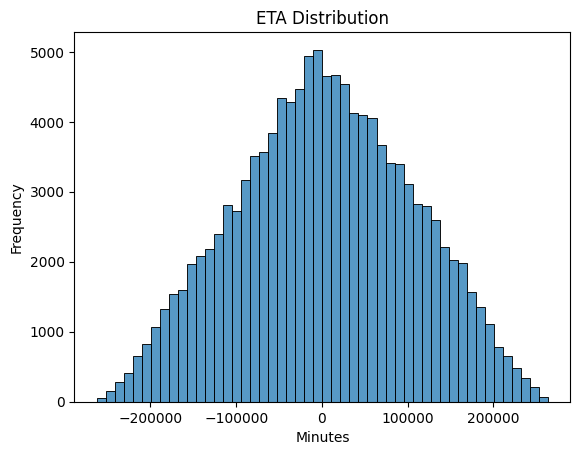

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['eta_minutes'], bins=50)
plt.title("ETA Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()


In [16]:
df.to_csv("final_cleaned_dataset_with_features.csv", index=False)


In [17]:
# Save to CSV
df.to_csv('final_dataset.csv', index=False)


In [18]:
from google.colab import files
files.download('final_dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
from datetime import datetime

# Convert to datetime if not already
dataset['pickup_time'] = pd.to_datetime(dataset['pickup_time'])
dataset['delivery_time'] = pd.to_datetime(dataset['delivery_time'])

# Target variable (ETA in minutes)
dataset['eta_minutes'] = (dataset['delivery_time'] - dataset['pickup_time']).dt.total_seconds() / 60

# Add time-based features
dataset['pickup_hour'] = dataset['pickup_time'].dt.hour
dataset['pickup_weekday'] = dataset['pickup_time'].dt.weekday
dataset['delivery_hour'] = dataset['delivery_time'].dt.hour

# Drop rows with missing values (or handle accordingly)
dataset = dataset.dropna(subset=['eta_minutes'])


In [20]:
features = [
    'pickup_hour', 'pickup_weekday', 'delivery_hour',
    'lng_x', 'lat_x', 'pickup_gps_lng', 'pickup_gps_lat',
    'delivery_gps_lng', 'delivery_gps_lat',
    'region_id_x', 'region_id_y', 'aoi_id_x', 'aoi_id_y',
]

X = dataset[features]
y = dataset['eta_minutes']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [22]:
print(X.shape)
print(y.shape)


(0, 13)
(0,)


In [23]:
dataset['pickup_time'] = pd.to_datetime(dataset['pickup_time'], errors='coerce')
dataset['delivery_time'] = pd.to_datetime(dataset['delivery_time'], errors='coerce')

# Now calculate ETA in minutes
dataset['eta_minutes'] = (dataset['delivery_time'] - dataset['pickup_time']).dt.total_seconds() / 60


In [24]:
print("Null ETAs:", dataset['eta_minutes'].isnull().sum())
print("Sample ETA values:", dataset['eta_minutes'].dropna().head())


Null ETAs: 0
Sample ETA values: Series([], Name: eta_minutes, dtype: float64)


In [25]:
print(dataset['pickup_time'].head(10))
print(dataset['delivery_time'].head(10))


Series([], Name: pickup_time, dtype: datetime64[ns])
Series([], Name: delivery_time, dtype: datetime64[ns])


In [26]:
dataset = pd.read_csv("/content/final_cleaned_dataset.csv")


In [27]:
# Fix and convert pickup_time and delivery_time
def fix_date(ts):
    try:
        return pd.to_datetime("2023-" + ts, format="%Y-%m-%d %H:%M:%S")
    except:
        return pd.NaT

dataset['pickup_time'] = dataset['pickup_time'].astype(str).apply(lambda x: fix_date(x))
dataset['delivery_time'] = dataset['delivery_time'].astype(str).apply(lambda x: fix_date(x))


In [28]:
dataset['eta_minutes'] = (dataset['delivery_time'] - dataset['pickup_time']).dt.total_seconds() / 60
print(dataset['eta_minutes'].dropna().head())


0     21713.0
1    100898.0
2    128447.0
3     73213.0
4    104079.0
Name: eta_minutes, dtype: float64


In [29]:
y = dataset['eta_minutes']


In [30]:
features = [
    'region_id_x', 'city_x', 'courier_id_x', 'lng_x', 'lat_x',
    'aoi_type_x', 'region_id_y', 'city_y', 'courier_id_y',
    'lng_y', 'lat_y', 'aoi_type_y'
]

X = dataset[features]


In [31]:
X = pd.get_dummies(X, columns=['city_x', 'city_y', 'aoi_type_x', 'aoi_type_y'], drop_first=True)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))


Random Forest MAE: 77381.28999416351
Random Forest R²: 0.1463704322939685


In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost R²:", r2_score(y_test, y_pred_xgb))


XGBoost MAE: 75023.8350107299
XGBoost R²: 0.1970899845836258


In [35]:
# Drop ETAs longer than 5 hours and shorter than 2 minutes
dataset = dataset[(dataset['eta_minutes'] >= 2) & (dataset['eta_minutes'] <= 300)]


In [36]:
features = [
    'region_id_x', 'courier_id_x', 'region_id_y', 'courier_id_y',
    'pickup_gps_lng', 'pickup_gps_lat',
    'delivery_gps_lng', 'delivery_gps_lat'
]
X = dataset[features]
y = dataset['eta_minutes']


In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['city_x'] = le.fit_transform(dataset['city_x'])
dataset['city_y'] = le.fit_transform(dataset['city_y'])


In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))


Random Forest MAE: 69.74126984126985
Random Forest R²: -0.06836723603158568


In [39]:
import xgboost as xgb
xgbr = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, seed=42)
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost R²:", r2_score(y_test, y_pred_xgb))


XGBoost MAE: 71.82090365697466
XGBoost R²: -0.11073842622417995


In [40]:
from math import radians, sin, cos, sqrt, atan2
import numpy as np

def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Feature 1: Distance
dataset['distance_km'] = dataset.apply(lambda row: haversine(
    row['pickup_gps_lng'], row['pickup_gps_lat'],
    row['delivery_gps_lng'], row['delivery_gps_lat']
), axis=1)

# Feature 2 & 3: Pickup time info
dataset['pickup_hour'] = dataset['pickup_time'].dt.hour
dataset['pickup_weekday'] = dataset['pickup_time'].dt.weekday

# Feature 4: Time window length
dataset['time_window_length'] = (
    pd.to_datetime(dataset['time_window_end'], errors='coerce') -
    pd.to_datetime(dataset['time_window_start'], errors='coerce')
).dt.total_seconds() / 60

# Feature 5: Log of distance (optional)
dataset['log_distance'] = np.log1p(dataset['distance_km'])

# Drop rows with missing engineered features
dataset = dataset.dropna(subset=[
    'distance_km', 'pickup_hour', 'pickup_weekday',
    'time_window_length', 'log_distance', 'eta_minutes'
])


/tmp/ipython-input-3236087229.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(dataset['time_window_end'], errors='coerce') -
/tmp/ipython-input-3236087229.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(dataset['time_window_start'], errors='coerce')


In [41]:
features = ['distance_km', 'log_distance', 'pickup_hour', 'pickup_weekday', 'time_window_length']
X = dataset[features]
y = dataset['eta_minutes']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [42]:
print(X.shape)
print(y.shape)


(0, 5)
(0,)


In [43]:
print(dataset.shape)
print(dataset['eta_minutes'].isnull().sum())


(0, 42)
0


In [45]:
import pandas as pd

# ✅ Only include columns that actually exist
dataset = pd.read_csv("/content/final_cleaned_dataset.csv", parse_dates=[
    'time_window_start',
    'time_window_end',
    'pickup_gps_time',
    'delivery_gps_time'
])

print(dataset.shape)
print(dataset.columns)
dataset.head()


(119932, 36)
Index(['order_id', 'region_id_x', 'city_x', 'courier_id_x', 'accept_time_x',
       'time_window_start', 'time_window_end', 'lng_x', 'lat_x', 'aoi_id_x',
       'aoi_type_x', 'pickup_time', 'pickup_gps_time', 'pickup_gps_lng',
       'pickup_gps_lat', 'accept_gps_time_x', 'accept_gps_lng_x',
       'accept_gps_lat_x', 'ds_x', 'region_id_y', 'city_y', 'courier_id_y',
       'lng_y', 'lat_y', 'aoi_id_y', 'aoi_type_y', 'accept_time_y',
       'accept_gps_time_y', 'accept_gps_lng_y', 'accept_gps_lat_y',
       'delivery_time', 'delivery_gps_time', 'delivery_gps_lng',
       'delivery_gps_lat', 'ds_y', 'courier_id'],
      dtype='object')


/tmp/ipython-input-1782622078.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = pd.read_csv("/content/final_cleaned_dataset.csv", parse_dates=[
/tmp/ipython-input-1782622078.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = pd.read_csv("/content/final_cleaned_dataset.csv", parse_dates=[
/tmp/ipython-input-1782622078.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset = pd.read_csv("/content/final_cleaned_dataset.csv", parse_dates=[
/tmp/ipython-input-1782622078.py:4: UserWarning: Could not infer format, so each element will be parsed individu

,order_id,region_id_x,city_x,courier_id_x,accept_time_x,time_window_start,time_window_end,lng_x,lat_x,aoi_id_x,aoi_type_x,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,accept_gps_time_x,accept_gps_lng_x,accept_gps_lat_x,ds_x,region_id_y,city_y,courier_id_y,lng_y,lat_y,aoi_id_y,aoi_type_y,accept_time_y,accept_gps_time_y,accept_gps_lng_y,accept_gps_lat_y,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,ds_y,courier_id
0,2545168,3,City1,317,06-05 07:36:00,06-05 09:00:00,06-05 11:00:00,106.46943,29.48868,337,1,06-05 09:44:00,06-05 09:43:00,106.46951,29.48856,06-24 08:42:00,120.31161,31.02090,605,1,City4,74,121.53263,31.12325,30175,14,06-20 10:17:00,06-20 10:17:00,121.52281,31.10600,06-20 11:37:00,06-20 11:37:00,121.53328,31.12313,620.0,317
1,923466,3,City1,317,06-06 07:35:00,06-06 09:00:00,06-06 11:00:00,106.46893,29.48812,337,1,06-06 09:06:00,06-06 09:06:00,106.46916,29.48858,06-24 08:42:00,120.31161,31.02090,606,129,City2,2688,126.52131,43.81248,53702,1,08-15 08:25:00,08-15 08:25:00,126.54445,43.85020,08-15 10:44:00,08-15 10:44:00,126.52100,43.81268,815.0,317
2,665830,3,City1,317,06-16 15:12:00,06-17 11:00:00,06-17 13:00:00,106.46808,29.48846,337,1,06-17 11:18:00,06-17 11:18:00,106.46458,29.48879,06-24 08:42:00,120.31161,31.02090,617,86,City5,2301,121.48689,37.44236,48311,1,09-14 14:10:00,09-14 14:10:00,121.48686,37.44345,09-14 16:05:00,09-14 16:05:00,121.48680,37.44297,914.0,317
3,246807,3,City1,317,05-21 12:30:00,05-21 12:30:00,05-21 14:30:00,106.46894,29.48817,337,1,05-21 13:05:00,05-21 13:05:00,106.46946,29.48900,05-21 12:30:00,106.47310,29.49119,521,129,City2,638,126.54541,43.83638,9272,1,07-11 08:32:00,07-11 08:32:00,126.54447,43.85028,07-11 09:18:00,07-11 09:18:00,126.54590,43.83737,711.0,317
4,3174021,3,City1,317,06-13 07:49:00,06-13 09:00:00,06-13 11:00:00,106.46918,29.48885,337,1,06-13 09:09:00,06-13 09:09:00,106.46930,29.48855,06-24 08:42:00,120.31161,31.02090,613,1,City4,4467,121.52312,31.07071,21192,14,08-24 14:36:00,08-24 14:36:00,121.52272,31.10596,08-24 15:48:00,08-24 15:48:00,121.52311,31.07075,824.0,317


In [46]:
from datetime import datetime

def add_year_and_parse(date_str):
    try:
        return datetime.strptime(f"2023-{date_str}", "%Y-%m-%d %H:%M:%S")
    except:
        return pd.NaT  # For any malformed data

# Apply only to those columns that need it
cols_to_fix = ['pickup_gps_time', 'delivery_gps_time']
for col in cols_to_fix:
    dataset[col] = dataset[col].apply(lambda x: add_year_and_parse(str(x)))


In [47]:
dataset = dataset[
    dataset['pickup_gps_time'].notnull() &
    dataset['delivery_gps_time'].notnull()
]


In [48]:
dataset['eta_minutes'] = (
    dataset['delivery_gps_time'] - dataset['pickup_gps_time']
).dt.total_seconds() / 60


In [49]:
print(dataset['eta_minutes'].describe())


count    119932.000000
mean      31626.507613
std       99616.649439
min     -261649.000000
25%      -34238.750000
50%       33567.500000
75%      108171.250000
max      261113.000000
Name: eta_minutes, dtype: float64


In [50]:
pd.to_datetime(dataset['pickup_gps_time'].head())


,pickup_gps_time
0,2023-06-05 09:43:00
1,2023-06-06 09:06:00
2,2023-06-17 11:18:00
3,2023-05-21 13:05:00
4,2023-06-13 09:09:00


In [51]:
print(dataset['delivery_gps_time'].head())
print(dataset['delivery_gps_time'].dtype)


0   2023-06-20 11:37:00
1   2023-08-15 10:44:00
2   2023-09-14 16:05:00
3   2023-07-11 09:18:00
4   2023-08-24 15:48:00
Name: delivery_gps_time, dtype: datetime64[ns]
datetime64[ns]


In [52]:
dataset['eta_minutes'] = (
    dataset['delivery_gps_time'] - dataset['pickup_gps_time']
).dt.total_seconds() / 60


In [53]:
print(dataset['eta_minutes'].describe())


count    119932.000000
mean      31626.507613
std       99616.649439
min     -261649.000000
25%      -34238.750000
50%       33567.500000
75%      108171.250000
max      261113.000000
Name: eta_minutes, dtype: float64


In [54]:
# Drop rows where pickup or delivery time is missing
dataset = dataset.dropna(subset=['pickup_gps_time', 'delivery_gps_time'])

# Keep only rows where delivery is after pickup
dataset = dataset[dataset['delivery_gps_time'] > dataset['pickup_gps_time']]


In [55]:
dataset['eta_minutes'] = (
    dataset['delivery_gps_time'] - dataset['pickup_gps_time']
).dt.total_seconds() / 60


In [56]:
dataset = dataset[(dataset['eta_minutes'] > 0) & (dataset['eta_minutes'] < 300)]


In [57]:
print(dataset['eta_minutes'].describe())


count    336.000000
mean     145.922619
std       78.988191
min        3.000000
25%       79.250000
50%      142.000000
75%      214.000000
max      299.000000
Name: eta_minutes, dtype: float64


In [69]:
final_cleaned_dataset['eta_minutes'] = (
    (final_cleaned_dataset['delivery_gps_time'] - final_cleaned_dataset['pickup_gps_time'])
    .dt.total_seconds() / 60
)


In [67]:
final_cleaned_dataset = dataset.copy()


In [70]:
# Replace 'dataset' below with the variable holding your 336-row filtered data
final_cleaned_dataset = dataset.copy()

# Save to CSV
final_cleaned_dataset.to_csv("/content/final_cleaned_dataset_336.csv", index=False)


In [71]:
import pandas as pd

final_cleaned_dataset = pd.read_csv(
    "/content/final_cleaned_dataset_336.csv",
    parse_dates=['pickup_gps_time', 'delivery_gps_time']
)


In [72]:
final_cleaned_dataset['eta_minutes'] = (
    (final_cleaned_dataset['delivery_gps_time'] - final_cleaned_dataset['pickup_gps_time'])
    .dt.total_seconds() / 60
)


In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load the filtered dataset (you already saved it earlier)
final_cleaned_dataset = pd.read_csv("/content/final_cleaned_dataset_336.csv", parse_dates=['pickup_gps_time', 'delivery_gps_time'])

# Recalculate ETA in minutes
final_cleaned_dataset['eta_minutes'] = (
    (final_cleaned_dataset['delivery_gps_time'] - final_cleaned_dataset['pickup_gps_time'])
    .dt.total_seconds() / 60
)

# Drop any rows with nulls (just in case)
final_cleaned_dataset = final_cleaned_dataset.dropna()

# Define your target variable
y = final_cleaned_dataset['eta_minutes']

# Drop unnecessary columns to form features (X)
X = final_cleaned_dataset.drop(columns=[
    'pickup_gps_time', 'delivery_gps_time', 'eta_minutes'
])

# Optional: Encode categorical columns if present
X = pd.get_dummies(X)

# Align X and y again to be safe
X, y = X.align(y, join='inner', axis=0)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------


**RANDOM FOREST**

In [74]:
 -----------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("🔹 Random Forest R²:", r2_score(y_test, y_pred_rf))

SyntaxError: invalid syntax (ipython-input-3377136914.py, line 1)

In [75]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load the filtered dataset (you already saved it earlier)
final_cleaned_dataset = pd.read_csv("/content/final_cleaned_dataset_336.csv", parse_dates=['pickup_gps_time', 'delivery_gps_time'])

# Recalculate ETA in minutes
final_cleaned_dataset['eta_minutes'] = (
    (final_cleaned_dataset['delivery_gps_time'] - final_cleaned_dataset['pickup_gps_time'])
    .dt.total_seconds() / 60
)

# Drop any rows with nulls (just in case)
final_cleaned_dataset = final_cleaned_dataset.dropna()

# Define your target variable
y = final_cleaned_dataset['eta_minutes']

# Drop unnecessary columns to form features (X)
X = final_cleaned_dataset.drop(columns=[
    'pickup_gps_time', 'delivery_gps_time', 'eta_minutes'
])

# Optional: Encode categorical columns if present
X = pd.get_dummies(X)

# Align X and y again to be safe
X, y = X.align(y, join='inner', axis=0)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# ✅ Random Forest
# -----------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("🔹 Random Forest R²:", r2_score(y_test, y_pred_rf))

# -----------------------------
# ✅ XGBoost
# -----------------------------
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("🔹 XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("🔹 XGBoost R²:", r2_score(y_test, y_pred_xgb))


🔹 Random Forest MAE: 65.46882352941178
🔹 Random Forest R²: 0.03071448532172172
🔹 XGBoost MAE: 69.24222845189712
🔹 XGBoost R²: -0.11877763352665305


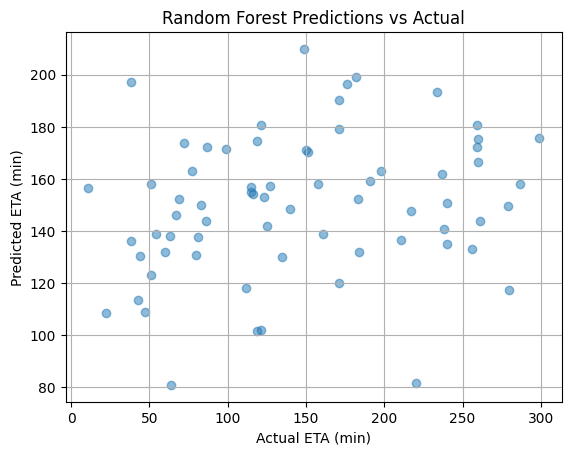

In [76]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual ETA (min)")
plt.ylabel("Predicted ETA (min)")
plt.title("Random Forest Predictions vs Actual")
plt.grid(True)
plt.show()
